In [1]:
################################################################
### Import Library
################################################################
import torch.nn.functional as F
from timeit import default_timer
import matplotlib.pyplot as plt
import numpy as np
from kgan_conv import *
import pyekfmm as fmm
from torch.utils.data import DataLoader, TensorDataset
import os
from scipy.ndimage.filters import gaussian_filter

torch.manual_seed(0)
np.random.seed(0)
import sys
print(sys.path)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

pred_path = "./prediction/KAN_FNO/Marmousi/"
os.makedirs(pred_path, exist_ok=True)

['', '/opt/madagascar/lib/python3.10/site-packages', '/home/g202321530/anaconda3/envs/pytorch/lib/python312.zip', '/home/g202321530/anaconda3/envs/pytorch/lib/python3.12', '/home/g202321530/anaconda3/envs/pytorch/lib/python3.12/lib-dynload', '/home/g202321530/anaconda3/envs/pytorch/lib/python3.12/site-packages']


/tmp/ipykernel_21613/48790366.py:12: DeprecationWarning: Please import `gaussian_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import gaussian_filter


In [6]:
################################################################
### Network Building
################################################################

class MLP(nn.Module):
    def __init__(self, in_channels, out_channels, mid_channels):
        super(MLP, self).__init__()
        self.mlp1 = nn.Conv2d(in_channels, mid_channels, 1)
        self.mlp2 = nn.Conv2d(mid_channels, out_channels, 1)

    def forward(self, x):
        x = self.mlp1(x)
        x = F.relu(x)
        x = self.mlp2(x)
        return x

class U_net(nn.Module):
    def __init__(self, input_channels, output_channels, kernel_size, dropout_rate):
        super(U_net, self).__init__()
        self.input_channels = input_channels
        self.conv1 = self.conv(input_channels, output_channels, kernel_size=kernel_size, stride=2,
                               dropout_rate=dropout_rate)
        self.conv2 = self.conv(input_channels, output_channels, kernel_size=kernel_size, stride=2,
                               dropout_rate=dropout_rate)
        self.conv2_1 = self.conv(input_channels, output_channels, kernel_size=kernel_size, stride=1,
                                 dropout_rate=dropout_rate)
        self.conv3 = self.conv(input_channels, output_channels, kernel_size=kernel_size, stride=2,
                               dropout_rate=dropout_rate)
        self.conv3_1 = self.conv(input_channels, output_channels, kernel_size=kernel_size, stride=1,
                                 dropout_rate=dropout_rate)

        self.deconv2 = self.deconv(input_channels, output_channels, kernel_size=3)
        self.deconv1 = self.deconv(input_channels * 2, output_channels, kernel_size=4)
        self.deconv0 = self.deconv(input_channels * 2, output_channels, kernel_size=3)

        self.output_layer = self.output(input_channels * 2, output_channels,
                                        kernel_size=kernel_size, stride=1, dropout_rate=dropout_rate)

    def forward(self, x):
        out_conv1 = self.conv1(x)
        out_conv2 = self.conv2_1(self.conv2(out_conv1))
        out_conv3 = self.conv3_1(self.conv3(out_conv2))
        out_deconv2 = self.deconv2(out_conv3)
        # print(out_conv2.shape, out_deconv2.shape)
        concat2 = torch.cat((out_conv2, out_deconv2), 1)
        out_deconv1 = self.deconv1(concat2)
        concat1 = torch.cat((out_conv1, out_deconv1), 1)
        out_deconv0 = self.deconv0(concat1)
        concat0 = torch.cat((x, out_deconv0), 1)
        out = self.output_layer(concat0)

        return out

    def conv(self, in_planes, output_channels, kernel_size, stride, dropout_rate):
        return nn.Sequential(
            nn.Conv2d(in_planes, output_channels, kernel_size=kernel_size,
                      stride=stride, padding=(kernel_size - 1) // 2, bias=False),
            nn.BatchNorm2d(output_channels),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout(dropout_rate)
        )

    def deconv(self, input_channels, output_channels, kernel_size):
        return nn.Sequential(
            nn.ConvTranspose2d(input_channels, output_channels, kernel_size=kernel_size,
                               stride=2, padding=1),
            nn.LeakyReLU(0.1, inplace=True)
        )

    def output(self, input_channels, output_channels, kernel_size, stride, dropout_rate):
        return nn.Conv2d(input_channels, output_channels, kernel_size=kernel_size,
                         stride=stride, padding=(kernel_size - 1) // 2)
        
class SpectralConv2d(nn.Module):
    """2D Spectral Convolutional Layer using Fourier Transform."""
    def __init__(self, in_channels, out_channels, modes1, modes2):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2
        self.scale = 1 / (in_channels * out_channels)
        self.weights1 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, modes1, modes2, dtype=torch.cfloat))
        self.weights2 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, modes1, modes2, dtype=torch.cfloat))
        self.mlp4 = MLP(self.in_channels, self.in_channels, self.out_channels)
        self.unet4 = U_net(self.in_channels, self.out_channels, 1, 0)

    def compl_mul2d(self, input, weights):
        return torch.einsum("bixy,ioxy->boxy", input, weights)

    def forward(self, x):
        batchsize = x.shape[0]
        x_ft = torch.fft.rfft2(x)
        # x_ft = self.unet4(x_ft)
        out_ft = torch.zeros(batchsize, self.out_channels, x.size(-2), x.size(-1) // 2 + 1, dtype=torch.cfloat, device=x.device)
        out_ft[:, :, :self.modes1, :self.modes2] = self.compl_mul2d(x_ft[:, :, :self.modes1, :self.modes2], self.weights1)
        out_ft[:, :, -self.modes1:, :self.modes2] = self.compl_mul2d(x_ft[:, :, -self.modes1:, :self.modes2], self.weights2)
        return torch.fft.irfft2(out_ft, s=(x.size(-2), x.size(-1)))



class KAGFNO2d(nn.Module):
    def __init__(self, modes1, modes2, width):
        super().__init__()
        self.modes1 = modes1
        self.modes2 = modes2
        self.width = width
        self.padding = 5
        
        # Input projection
        self.p = nn.Linear(3, self.width)
        
        # Spectral Convolutions
        self.conv0 = SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
        self.conv1 = SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
        self.conv2 = SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
        self.conv3 = SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
        
        # U-Net blocks
        self.unet1 = U_net(self.width, self.width, 1, 0)
        self.unet2 = U_net(self.width, self.width, 1, 0)
        self.unet3 = U_net(self.width, self.width, 1, 0)
        
        # MLP blocks
        self.mlp0 = MLP(self.width, self.width, self.width)
        self.mlp1 = MLP(self.width, self.width, self.width)
        self.mlp2 = MLP(self.width, self.width, self.width)
        self.mlp3 = MLP(self.width, self.width, self.width)

        
        # KAN layer
        self.k0 = KAGNConv2DLayer(input_dim=self.width, output_dim=self.width, kernel_size=1)
        self.k1 = KAGNConv2DLayer(input_dim=self.width, output_dim=self.width, kernel_size=1)
        self.k2 = KAGNConv2DLayer(input_dim=self.width, output_dim=self.width, kernel_size=1)
        self.k3 = KAGNConv2DLayer(input_dim=self.width, output_dim=self.width, kernel_size=1)

        
        self.w0 = nn.Conv2d(self.width, self.width, 1)
        self.w1 = nn.Conv2d(self.width, self.width, 1)
        self.w2 = nn.Conv2d(self.width, self.width, 1)
        self.w3 = nn.Conv2d(self.width, self.width, 1)
    
        # Output projection
        self.q = MLP(self.width, 1, self.width * 4)

    def forward(self, x):
        x = x.to(torch.float32)
        grid = self.get_grid(x.shape, x.device)
        x = torch.cat((x, grid), dim=-1)
        x = self.p(x)
        x = x.permute(0, 3, 1, 2)
        x = F.pad(x, [0, self.padding, 0, self.padding])

        x1 = self.conv0(x)
        x1 = self.mlp0(x1)
        x2 = self.k0(x)
        xx0 = x1 + x2 + x
        

        x1 = self.conv1(xx0)
        x1 = self.mlp1(x1)
        x2 = self.k1(xx0)
        xx1 = x1 + x2 + x
        

        x1 = self.conv2(xx1)
        x1 = self.mlp2(x1)
        x2 = self.k2(xx1)
        xx2 = x1 + x2 + x

        
        x1 = self.conv3(xx2)
        x1 = self.mlp2(x1)
        x2 = self.k3(xx2)
        x = x1 + x2

        
        x = x[..., :-self.padding, :-self.padding]
        x = self.q(x)
        x = x.permute(0, 2, 3, 1)
        return x

    def get_grid(self, shape, device):
        batchsize, size_x, size_y = shape[0], shape[1], shape[2]
        gridx = torch.linspace(0, 1, size_x, dtype=torch.float, device=device)
        gridx = gridx.reshape(1, size_x, 1, 1).repeat([batchsize, 1, size_y, 1])
        gridy = torch.linspace(0, 1, size_y, dtype=torch.float, device=device)
        gridy = gridy.reshape(1, 1, size_y, 1).repeat([batchsize, size_x, 1, 1])
        return torch.cat((gridx, gridy), dim=-1)

Velocity model loaded. Shape: (240, 737)


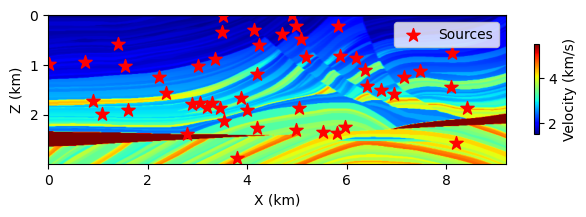

Final shapes:
T0_data_all: (50, 240, 737)
T_data_all: (50, 240, 737)
vel_data_all: (50, 240, 737)
src_data_all: (50, 240, 737)
Tau_data_all: (50, 240, 737)


In [7]:
################################################################
### Data Generation  Pyekfmm: https://github.com/aaspip/pyekfmm/tree/main/pyekfmm
################################################################
# Hyperparameters
n_sources = 50 # Number of sources
nz, nx = 240, 737  # Grid dimensions
dx, dz = 0.0125, 0.0125  # Grid spacing in km

# Initialize data containers
T0_data_all = np.zeros((n_sources, nz, nx), dtype='float32')
T_data_all = np.zeros((n_sources, nz, nx), dtype='float32')
vel_data_all = np.zeros((n_sources, nz, nx), dtype='float32')
src_data_all = np.zeros((n_sources, nz, nx), dtype='float32')

# Load velocity model
try:
    with open('./vel_model/marmousi/marmvz.bin', 'rb') as fd:
        velzz = np.fromfile(fd, dtype=np.float32).reshape([nz, nx], order='F')  # [z, x]
    velz = velzz / 1000  # Convert velocity to km/s
    print(f"Velocity model loaded. Shape: {velz.shape}")
except FileNotFoundError:
    print("Error: Velocity model file not found. Using random data for debugging.")
    velz = np.random.rand(nz, nx) * 3 + 1  # Random velocity between 1 and 4 km/s

# Generate random source points
#### Remember here we need to chose a different seed than that one in the training process
np.random.seed(20252025)  # For reproducibility
source_locs = np.random.randint(0, [nx, nz], size=(n_sources, 2)).astype('float32')  # [x, z]

# Convert to physical coordinates (km)
source_locs_physical = source_locs * [dx, dz]

# Visualization of velocity model with source locations
plt.figure()
plt.imshow(velz, extent=[0, (nx-1)*dx, (nz-1)*dz, 0], cmap='jet')
plt.colorbar(shrink=0.2, label='Velocity (km/s)')
plt.scatter(source_locs_physical[:, 0], source_locs_physical[:, 1], c='red', marker='*', s=100, label='Sources')
plt.xlabel('X (km)')
plt.ylabel('Z (km)')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Calculate traveltime fields for each source
for src_idx, (sx, sz) in enumerate(source_locs):
    sx, sz = int(sx), int(sz)  # Convert to integer indices
    src_physical = np.array([sz * dz, 0, sx * dx], dtype='float32')  # [x, y, z] in km

    # Populate velocity and source data
    vel_data_all[src_idx] = velz
    src_data_all[src_idx, sz, sx] = 1

    # Heterogeneous velocity computation
    velz_1d = velz.transpose().flatten(order='F')  # [z, x] -> [x, z]
    t = fmm.eikonal(
        velz_1d,
        xyz=src_physical,  # [x, y, z]
        ax=[0, dz, nz],  # x-axis
        ay=[0, dx, 1],   # y-axis (not used in 2D)
        az=[0, dx, nx],  # z-axis
        order=2
    )
    T_data_all[src_idx] = t.reshape(nz, nx, order='F')  # Reshape to [z, x]

    # Homogeneous velocity computation
    vel_homo = velz[sz, sx] * np.ones([nz * nx], dtype='float32')
    t1 = fmm.eikonal(
        vel_homo,
        xyz=src_physical,  # [x, y, z]
        ax=[0, dz, nz],  # x-axis
        ay=[0, dx, 1],   # y-axis (not used in 2D)
        az=[0, dx, nx],  # z-axis
        order=2
    )
    T0_data_all[src_idx] = t1.reshape(nz, nx, order='F')  # Reshape to [z, x]

# Compute Tau data
Tau_data_all = T_data_all - T0_data_all  # Shape: (n_sources, nz, nx)

# Print final shapes
print("Final shapes:")
print(f"T0_data_all: {T0_data_all.shape}")
print(f"T_data_all: {T_data_all.shape}")
print(f"vel_data_all: {vel_data_all.shape}")
print(f"src_data_all: {src_data_all.shape}")
print(f"Tau_data_all: {Tau_data_all.shape}")

# np.save(f'{pred_path}Test_T0_src{n_sources}.npy', T0_data_all)
# np.save(f'{pred_path}Test_Tau_src{n_sources}.npy', Tau_data_all)

In [8]:
################################################################
### Training dataset splitting
################################################################
inputs = torch.tensor(T0_data_all.reshape(T0_data_all.shape[0], T0_data_all.shape[1], T0_data_all.shape[2], 1), 
                      dtype=torch.float, requires_grad=True, device=device)
labels = torch.tensor(Tau_data_all, dtype=torch.float, requires_grad=True, device=device)

test_dataset = TensorDataset(inputs, labels)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

In [9]:
################################################################
### Prediction
################################################################
modes1, modes2 = 8, 8
width = 8
# batch_size = 40

def count_params(model):
    """Count the total number of trainable parameters in the model."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Load trained model
model = KAGFNO2d(modes1=modes1, modes2=modes2, width=width)
model_path = f"./model/Marmousi/KAGFNO/KAGFNO_marmousi_ep2000_modes{modes1}{modes2}_width{width}_0310.pth"
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location=device))
    print(f"Loaded model from {model_path}")
else:
    raise FileNotFoundError(f"Model file not found at {model_path}")
model.to(device)
print(f"Model parameters: {count_params(model):,}")



def predict(model, test_loader, device):
    model.eval()
    predictions = []
    with torch.no_grad():
        for batch_inputs, _ in test_loader:  # Ignore labels during prediction
            outputs = model(batch_inputs)
            predictions.append(outputs.cpu().numpy())  # Move to CPU and convert to numpy
    return np.concatenate(predictions, axis=0)

# Make predictions on validation set
test_predictions = predict(model, test_loader, device)
test_predictions = torch.tensor(test_predictions, dtype=torch.float, device=device)  # Convert back to tensor for comparison if needed
# np.save(f'{pred_path}KAGFNO_Pred_Tau_src{n_sources}_ep2000.npy', test_predictions.cpu().detach().numpy())

/tmp/ipykernel_21613/497116052.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))


Loaded model from ./model/Marmousi/KAGFNO/KAGFNO_marmousi_ep2000_modes88_width8_0310.pth
Model parameters: 66,209


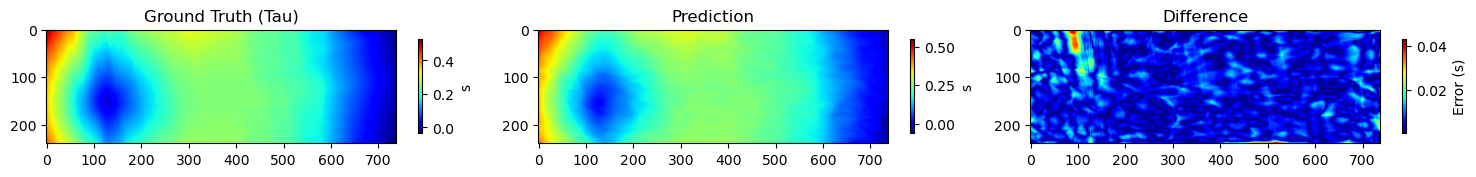

Mean Squared Error (MSE): 4.714e-05


In [11]:
################################################################
### Prediction Visualization (Tau)
################################################################
ii = 1
# Visualization of predictions vs ground truth (first sample as an example)
plt.figure(figsize=(15, 5))

# Ground truth (Tau_data)
plt.subplot(1, 3, 1)
plt.imshow(labels[ii].cpu().detach().numpy(), cmap='jet')
plt.title('Ground Truth (Tau)')
plt.colorbar(label='s', shrink=0.2)

# Prediction
plt.subplot(1, 3, 2)
plt.imshow(test_predictions[ii].cpu().detach().numpy().squeeze(), cmap='jet')
plt.title('Prediction')
plt.colorbar(label='s', shrink=0.2)

# Difference
plt.subplot(1, 3, 3)
plt.imshow(np.abs((labels[ii] - test_predictions[ii].squeeze()).cpu().detach().numpy()), cmap='jet')
plt.title('Difference')
plt.colorbar(label='Error (s)', shrink=0.2)

plt.tight_layout()
plt.show()

mse = np.mean((labels[ii].cpu().detach().numpy() - test_predictions[ii].cpu().detach().numpy().squeeze()) ** 2)
print(f"Mean Squared Error (MSE): {mse:.3e}")

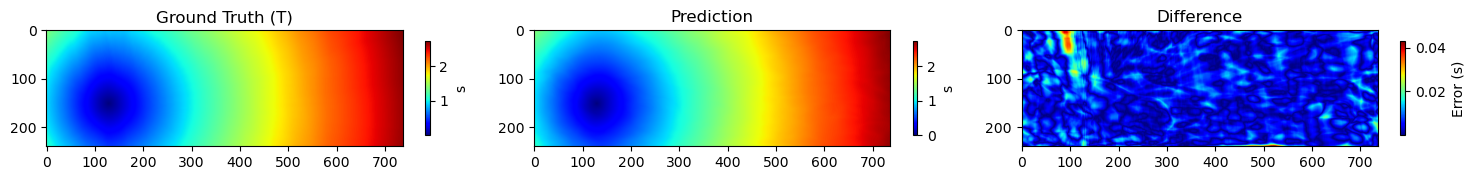

Mean Squared Error (MSE): 4.714e-05


In [12]:
################################################################
### Prediction Visualization (T)
################################################################
# Visualization of predictions vs ground truth (first sample as an example)
plt.figure(figsize=(15, 5))

# Ground truth (Tau_data)
plt.subplot(1, 3, 1)
plt.imshow((labels[ii]+inputs[ii,:,:,0]).cpu().detach().numpy(), cmap='jet')
plt.title('Ground Truth (T)')
plt.colorbar(label='s', shrink=0.2)

# Prediction
plt.subplot(1, 3, 2)
plt.imshow((test_predictions[ii]+inputs[ii]).cpu().detach().numpy().squeeze(), cmap='jet')
plt.title('Prediction')
plt.colorbar(label='s', shrink=0.2)

# Difference
plt.subplot(1, 3, 3)
plt.imshow(np.abs((labels[ii] - test_predictions[ii].squeeze()).cpu().detach().numpy()), cmap='jet')
plt.title('Difference')
plt.colorbar(label='Error (s)', shrink=0.2)

plt.tight_layout()
plt.show()

mse = np.mean((labels[ii].cpu().detach().numpy() - test_predictions[ii].cpu().detach().numpy().squeeze()) ** 2)
print(f"Mean Squared Error (MSE): {mse:.3e}")

Mean MSE: 3.118e-04
Std MSE: 2.743e-04
Min MSE: 3.456e-05
Max MSE: 1.584e-03


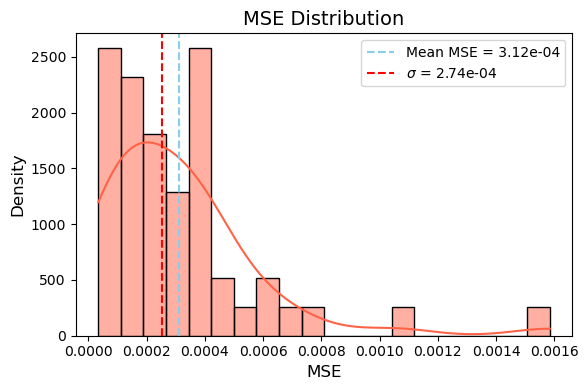

In [14]:
################################################################
### Plot MSE error distribution
################################################################
import seaborn as sns

# Calculate MSE per source
mse_per_source = np.mean((labels.cpu().detach().numpy() - test_predictions.cpu().detach().numpy().squeeze(-1)) ** 2, axis=(1, 2))

# Print some statistics
print(f"Mean MSE: {np.mean(mse_per_source):.3e}")
print(f"Std MSE: {np.std(mse_per_source):.3e}")
print(f"Min MSE: {np.min(mse_per_source):.3e}")
print(f"Max MSE: {np.max(mse_per_source):.3e}")

# Plot the MSE distribution
plt.figure(figsize=(6, 4))

# Histogram with KDE
sns.histplot(mse_per_source, bins=20, kde=True, color='tomato', stat='density', alpha=0.5)

# Add labels and title
plt.xlabel('MSE', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('MSE Distribution', fontsize=14)

# Add vertical lines for mean and median
plt.axvline(np.mean(mse_per_source), color='skyblue', linestyle='--', 
            label=f'Mean MSE = {np.mean(mse_per_source):.2e}')
plt.axvline(np.median(mse_per_source), color='red', linestyle='--', 
            label=f'$\\sigma$ = {np.std(mse_per_source):.2e}')
plt.legend()

# Adjust layout and show plot
plt.tight_layout()
plt.show()

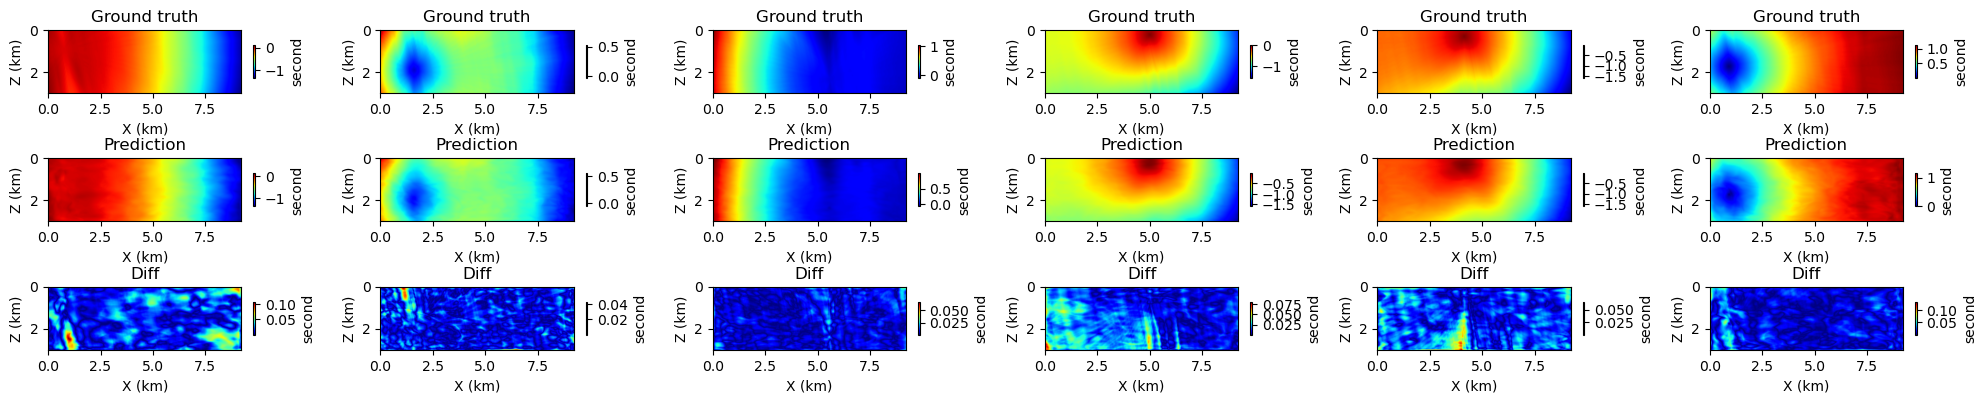

In [19]:
################################################################
### Prediction Visualization Different Sources
################################################################
## Visualization of the first 5 results (T, T0, and Tau)
fig, axes = plt.subplots(3, 6, figsize=(20, 4))
for i in range(6):
    # T data
    im0 = axes[0, i].imshow(labels[i].cpu().detach().numpy(), extent=[0, nx*dx, nz*dz, 0], cmap='jet')
    axes[0, i].set_title(f"Ground truth")
    axes[0, i].set_xlabel('X (km)')
    axes[0, i].set_ylabel('Z (km)')
    cbar0 = fig.colorbar(im0, ax=axes[0, i], shrink=0.4, pad=0.05)
    cbar0.set_label('second')

    # T0 data
    im1 = axes[1, i].imshow(test_predictions[i].cpu().detach().numpy().squeeze(), extent=[0, nx*dx, nz*dz, 0], cmap='jet')
    axes[1, i].set_title(f"Prediction")
    axes[1, i].set_xlabel('X (km)')
    axes[1, i].set_ylabel('Z (km)')
    cbar1 = fig.colorbar(im1, ax=axes[1, i], shrink=0.4, pad=0.05)
    cbar1.set_label('second')

    # Tau = T - T0
    im2 = axes[2, i].imshow(np.abs((labels[i] - test_predictions[i].squeeze()).cpu().detach().numpy()), extent=[0, nx*dx, nz*dz, 0], cmap='jet')
    axes[2, i].set_title(f"Diff")
    axes[2, i].set_xlabel('X (km)')
    axes[2, i].set_ylabel('Z (km)')
    cbar2 = fig.colorbar(im2, ax=axes[2, i], shrink=0.4, pad=0.05)
    cbar2.set_label('second')

plt.tight_layout()
plt.show()

In [ ]:
################################################################
### Prediction Visualization Different Sources (In Percent)
################################################################
# Visualization of the first 5 results (Ground Truth, Prediction, Absolute Percentage Error)
fig, axes = plt.subplots(3, 8, figsize=(24, 4))

for i in range(0, 8):
    # Ground truth (Tau_data)
    true_data = labels[i].cpu().detach().numpy() # Remove channel dim if present
    im0 = axes[0, i].imshow(true_data, extent=[0, nx*dx, nz*dz, 0], cmap='jet')
    axes[0, i].set_title(f"Ground Truth {i+1}")
    axes[0, i].set_xlabel('X (km)')
    axes[0, i].set_ylabel('Z (km)')
    cbar0 = fig.colorbar(im0, ax=axes[0, i], shrink=0.4, pad=0.05)
    cbar0.set_label('Seconds')

    # Prediction
    pred_data = test_predictions[i].cpu().detach().numpy().squeeze()  # Remove channel dim if present
    im1 = axes[1, i].imshow(pred_data, extent=[0, nx*dx, nz*dz, 0], cmap='jet')
    axes[1, i].set_title(f"Prediction {i+1}")
    axes[1, i].set_xlabel('X (km)')
    axes[1, i].set_ylabel('Z (km)')
    cbar1 = fig.colorbar(im1, ax=axes[1, i], shrink=0.4, pad=0.05)
    cbar1.set_label('Seconds')

    # Absolute Percentage Error
    abs_error = np.abs(pred_data - true_data)  # Absolute difference
    max_true = np.max(np.abs(true_data))       # Maximum absolute value of ground truth
    ape = (abs_error / max_true) * 100         # Absolute percentage error
    im2 = axes[2, i].imshow(ape, extent=[0, nx*dx, nz*dz, 0], cmap='jet')
    axes[2, i].set_title(f"APE {i+1}")
    axes[2, i].set_xlabel('X (km)')
    axes[2, i].set_ylabel('Z (km)')
    cbar2 = fig.colorbar(im2, ax=axes[2, i], shrink=0.4, pad=0.05)
    cbar2.set_label('%')

plt.tight_layout()
plt.show()